# Build the fine-tuning dataset: `pixels.json` → DINOv2 `features.npy` (Step 3a)

Port of `STEPP/utils/make_dataset.py`. For every image it turns the projected future-path
pixels (from notebook 03) into the autoencoder's **positive / traversable training set**:

image → resize 700×700 → SLIC superpixels → keep the segments the **path pixels land on**
→ DINOv2 `vits14` dense features (50×50×384) → average one **384-d vector per path segment**.
Stacking those vectors over all images gives `features.npy` (N_segments × 384), exactly the
data `training.py` reconstructs in notebook 06.

**Consistency note:** SLIC + DINOv2 run on a 700×700 **square** (same geometry as the
zero-shot eval in notebook 04), so the fine-tuned model sees the same feature distribution it
will be evaluated on. Path pixels (stored full-res 1920×1200) are rescaled to 700×700 here.

**Deviations from the repo (documented):** DINOv2 via `torch.hub`, SLIC via `skimage`
(`fast_slic`/`pytictac` unavailable on Windows); same params `n_segments=400, compactness=15`,
input 700, patch 14 → 50×50.

## 0. Config

In [7]:
from pathlib import Path

DATA_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Rellis_3D')
OUT_ROOT  = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/outputs')

# sequences to build features for -- each must already have outputs/<SEQ>/pixels.json from notebook 03
#SEQS = ['00000']
SEQS = ['00001','00002','00003','00004']

IMG_W, IMG_H = 1920, 1200
INPUT_SIZE   = 700
PATCH        = 14
FEAT         = INPUT_SIZE // PATCH      # 50
N_SEGMENTS   = 400
COMPACTNESS  = 15

for seq in SEQS:
    pj = OUT_ROOT / seq / 'pixels.json'
    assert pj.is_file(), f'missing {pj} -- run notebook 03 for sequence {seq} first'
print('will build features for:', SEQS)

will build features for: ['00001', '00002', '00003', '00004']


## 1. Load DINOv2 backbone

ref - 
https://www.kaggle.com/code/shravankumar147/02-dino-v2-from-torch-hub
https://github.com/facebookresearch/dinov2

( i found verbose = F doesnt give me unnecessary messsages, reduced visual clutter )

In [8]:
import warnings, json, time
warnings.filterwarnings('ignore')
import numpy as np
import cv2
import torch
from torchvision import transforms as T
from skimage.segmentation import slic as sk_slic
import matplotlib.pyplot as plt
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **k: x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False).to(device).eval()
for p in dino.parameters():
    p.requires_grad = False
_normalize = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

@torch.no_grad()
def dino_features(rgb_square_uint8):
    """700x700 RGB uint8 -> (384, 50, 50) dense feature map."""
    t = torch.from_numpy(rgb_square_uint8).permute(2, 0, 1).float() / 255.0
    t = _normalize(t)[None].to(device)
    feat = dino.get_intermediate_layers(t)[0].reshape(1, FEAT, FEAT, -1).permute(0, 3, 1, 2)
    return feat[0]
print('DINOv2 ready')

device: cuda
DINOv2 ready


## 2. Per-image feature extraction

`image_path_features` returns the averaged 384-d DINOv2 vector for each SLIC segment that the
future path drives over (optionally also the hit-segment map for visualization).

In [9]:
SX, SY = INPUT_SIZE / IMG_W, INPUT_SIZE / IMG_H

@torch.no_grad()
def image_path_features(img_path, path_pixels, return_seg=False):
    bgr = cv2.imread(str(img_path)); assert bgr is not None, img_path
    sq = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), (INPUT_SIZE, INPUT_SIZE))
    seg = sk_slic(sq, n_segments=N_SEGMENTS, compactness=COMPACTNESS, start_label=0, channel_axis=-1)

    # rescale full-res path pixels (u,v) to the 700x700 square and find the segments they hit
    p = np.asarray(path_pixels, dtype=float)
    u = np.clip((p[:, 0] * SX).astype(int), 0, INPUT_SIZE - 1)
    v = np.clip((p[:, 1] * SY).astype(int), 0, INPUT_SIZE - 1)
    hit_ids = np.unique(seg[v, u])

    feats = dino_features(sq)                                  # (384, 50, 50)
    seg50 = cv2.resize(seg.astype(np.int32), (FEAT, FEAT), interpolation=cv2.INTER_NEAREST)
    vecs, kept = [], []
    for sid in hit_ids:
        m = seg50 == sid
        if m.any():                                            # skip segments that vanish at 50x50
            vecs.append(feats[:, m].mean(dim=1))
            kept.append(sid)
    out = np.stack([x.cpu().numpy() for x in vecs]) if vecs else np.zeros((0, 384), np.float32)
    return (out, seg, np.array(kept)) if return_seg else out

## 3. Sanity check - visualize which segments the path selects

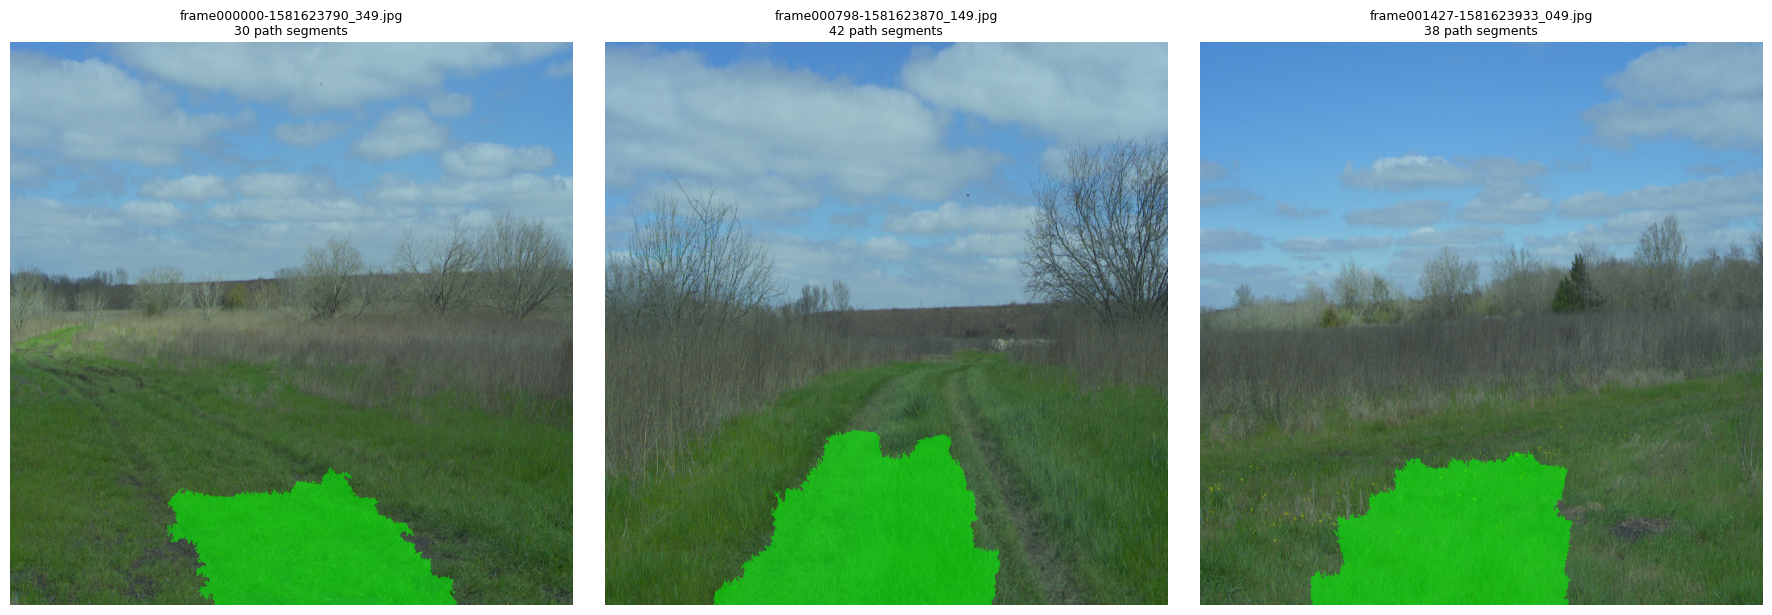

In [10]:
seq0 = SEQS[0]
pix0 = json.load(open(OUT_ROOT / seq0 / 'pixels.json'))
names0 = [n for n in sorted(pix0) if pix0[n]]
img_dir0 = DATA_ROOT / seq0 / 'pylon_camera_node'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name in zip(axes, names0[::max(1, len(names0)//3)][:3]):
    sq = cv2.resize(cv2.cvtColor(cv2.imread(str(img_dir0 / name)), cv2.COLOR_BGR2RGB), (INPUT_SIZE, INPUT_SIZE))
    _, seg, kept = image_path_features(img_dir0 / name, pix0[name], return_seg=True)
    mask = np.isin(seg, kept)
    vis = sq.copy(); vis[mask] = (0.45 * vis[mask] + 0.55 * np.array([0, 255, 0])).astype(np.uint8)
    ax.imshow(vis); ax.set_title(f'{name}\n{len(kept)} path segments', fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Build & save `features.npy` per sequence

In [11]:
for seq in SEQS:
    pix = json.load(open(OUT_ROOT / seq / 'pixels.json'))
    img_dir = DATA_ROOT / seq / 'pylon_camera_node'
    names = [n for n in sorted(pix) if pix[n]]                 # skip empty-path frames
    print(f'\n=== {seq}: {len(names)} frames with a path ===')

    chunks, n_segs = [], []
    t0 = time.time()
    for name in tqdm(names):
        v = image_path_features(img_dir / name, pix[name])
        if len(v):
            chunks.append(v); n_segs.append(len(v))
    features = np.concatenate(chunks, axis=0).astype(np.float32)

    out_npy = OUT_ROOT / seq / 'features.npy'
    np.save(out_npy, features)
    meta = {
        'sequence': seq, 'n_frames': len(names), 'n_segments_total': int(features.shape[0]),
        'feature_dim': int(features.shape[1]), 'backbone': 'dinov2_vits14',
        'input_size': INPUT_SIZE, 'n_segments': N_SEGMENTS, 'compactness': COMPACTNESS,
        'segments_per_frame_p10_50_90': np.percentile(n_segs, [10, 50, 90]).astype(int).tolist(),
        'has_nan': bool(np.isnan(features).any()),
        'slic': 'skimage (fast_slic unavailable on Windows)',
    }
    json.dump(meta, open(OUT_ROOT / seq / 'features_meta.json', 'w'), indent=2)
    print(f'{seq}: {features.shape} in {time.time()-t0:.0f}s  ->  {out_npy} '
          f'({out_npy.stat().st_size/1e6:.0f} MB), NaN={meta["has_nan"]}')
    print('  segments/frame p10/50/90:', meta['segments_per_frame_p10_50_90'])


=== 00001: 1879 frames with a path ===


100%|██████████| 1879/1879 [1:01:55<00:00,  1.98s/it]  


00001: (77517, 384) in 3715s  ->  s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00001\features.npy (119 MB), NaN=False
  segments/frame p10/50/90: [27, 41, 56]

=== 00002: 3441 frames with a path ===


100%|██████████| 3441/3441 [1:49:57<00:00,  1.92s/it]     


00002: (186383, 384) in 6598s  ->  s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00002\features.npy (286 MB), NaN=False
  segments/frame p10/50/90: [38, 55, 70]

=== 00003: 1734 frames with a path ===


100%|██████████| 1734/1734 [18:31<00:00,  1.56it/s]


00003: (67853, 384) in 1112s  ->  s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00003\features.npy (104 MB), NaN=False
  segments/frame p10/50/90: [25, 40, 53]

=== 00004: 1692 frames with a path ===


100%|██████████| 1692/1692 [17:57<00:00,  1.57it/s]


00004: (60257, 384) in 1078s  ->  s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\outputs\00004\features.npy (93 MB), NaN=False
  segments/frame p10/50/90: [24, 35, 49]


## 5. Quick look at the feature distribution

These traversable-segment features are what notebook 06's autoencoder learns to reconstruct.

features.npy: (77517, 384) | mean 0.0049 | std 2.3772


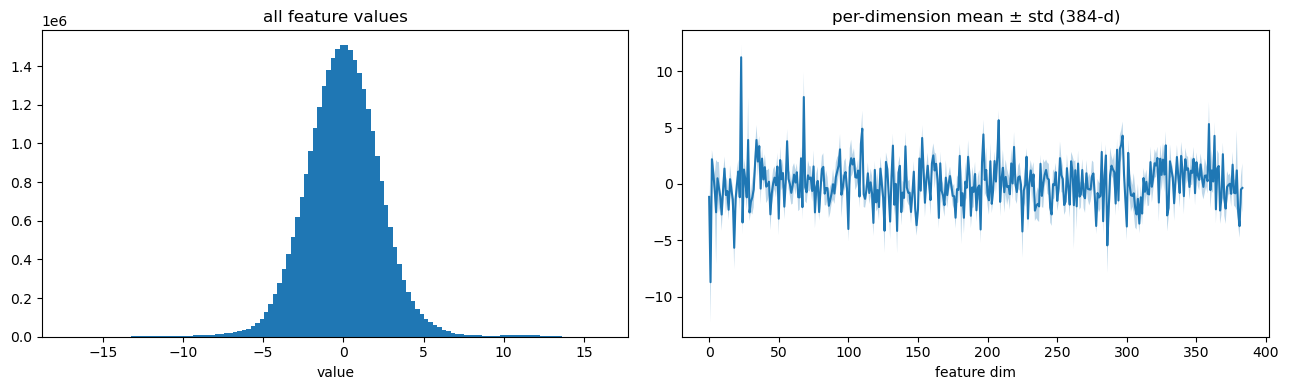

In [13]:
feats = np.load(OUT_ROOT / SEQS[0] / 'features.npy')
print('features.npy:', feats.shape, '| mean', round(feats.mean(), 4), '| std', round(feats.std(), 4))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(feats.ravel(), bins=120); ax[0].set(title='all feature values', xlabel='value')
ax[1].plot(feats.mean(0)); ax[1].fill_between(range(384), feats.mean(0)-feats.std(0), feats.mean(0)+feats.std(0), alpha=0.3)
ax[1].set(title='per-dimension mean ± std (384-d)', xlabel='feature dim')
plt.tight_layout(); plt.show()